<a href="https://colab.research.google.com/github/fadeeva/nakedML/blob/master/MLnotes/002.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

from scipy import stats

import seaborn as sns
import matplotlib.pyplot as plt

plt.style.use('ggplot')

In [2]:
import kagglehub

path = kagglehub.dataset_download("kumarajarshi/life-expectancy-who")
print("Path to dataset files:", path)

100%|██████████| 119k/119k [00:00<00:00, 297kB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/kumarajarshi/life-expectancy-who/versions/1


In [3]:
rng = np.random.default_rng()

In [4]:
df = pd.read_csv(f'{path}/Life Expectancy Data.csv')
df.drop('Status', inplace=True, axis=1)
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)
df.head()

,Country,Year,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,65.0,263.0,62,0.01,71.279624,65.0,1154,19.1,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,59.9,271.0,64,0.01,73.523582,62.0,492,18.6,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,59.9,268.0,66,0.01,73.219243,64.0,430,18.1,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,59.5,272.0,69,0.01,78.184215,67.0,2787,17.6,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,59.2,275.0,71,0.01,7.097109,68.0,3013,17.2,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


# /02
*part 2*

## Data Normalization

### Min-max

All values in the interval [0, 1]

$$
p'_i = \frac{p_i - min\{p_i\}}{max\{p_i\} - min\{p_i\}}
$$

Skew:
Original: -0.63
Normalized: -0.63


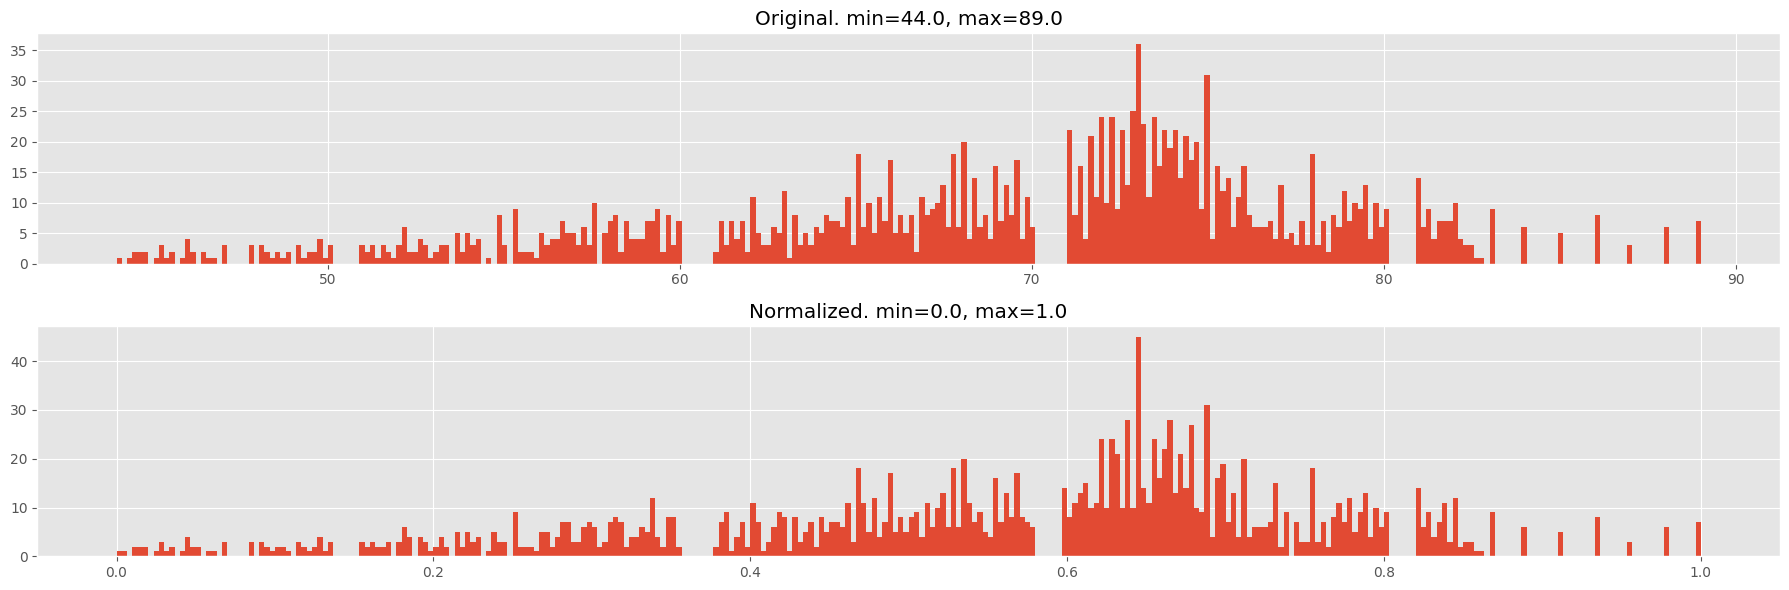

In [5]:
life_exp_norm = (df['Life expectancy '] - df['Life expectancy '].min()) / \
(df['Life expectancy '].max() - df['Life expectancy '].min())

print(f'Skew:\nOriginal: {np.round(stats.skew(df['Life expectancy ']), 2)}')
print(f'Normalized: {np.round(stats.skew(life_exp_norm), 2)}')

fig, axs = plt.subplots(2, 1, figsize=(18, 6))

axs[0].hist(df['Life expectancy '], bins=300)
axs[0].set_title(f'Original. min={df['Life expectancy '].min()}, max={df['Life expectancy '].max()}')

axs[1].hist(life_exp_norm, bins=300)
axs[1].set_title(f'Normalized. min={life_exp_norm.min()}, max={life_exp_norm.max()}')

plt.tight_layout()

### Z-score
The mean will be 0, standard deviation 1
$$
p_i = \frac{p_i - \mu}{\sigma}
$$

Skew:
Original: -2.36
Normalized: -2.36


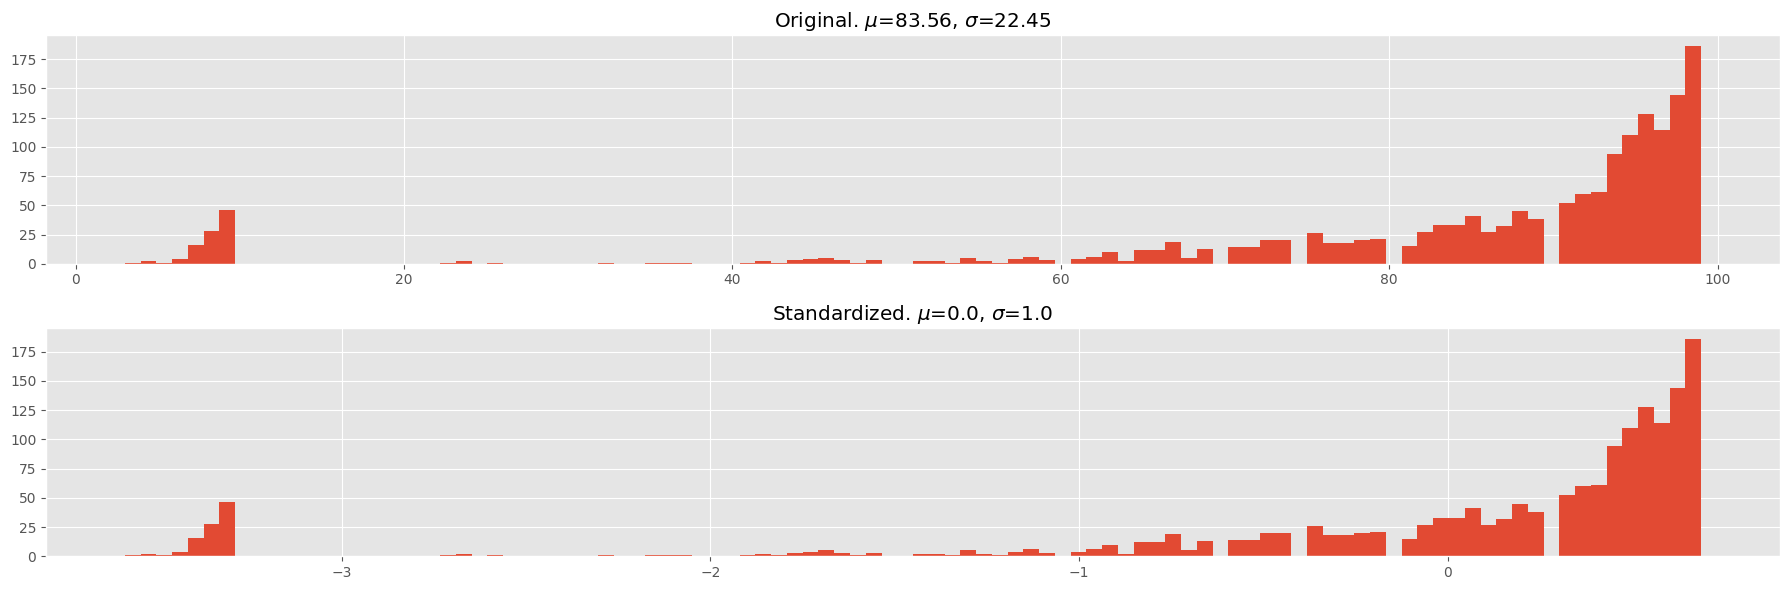

In [6]:
polio_z = (df['Polio'] - df['Polio'].mean()) / df['Polio'].std()

print(f'Skew:\nOriginal: {np.round(stats.skew(df['Polio']), 2)}')
print(f'Normalized: {np.round(stats.skew(polio_z), 2)}')

fig, axs = plt.subplots(2, 1, figsize=(18, 6))

axs[0].hist(df['Polio'], bins=100)
axs[0].set_title(fr'Original. $\mu$={np.round(df['Polio'].mean(), 2)}, $\sigma$={np.round(df['Polio'].std(), 2)}')

axs[1].hist(polio_z, bins=100)
axs[1].set_title(fr'Standardized. $\mu$={np.round(polio_z.mean(), 2)}, $\sigma$={np.round(polio_z.std(), 2)}')

plt.tight_layout()

### Logarithm

Used for highly skewed data

Skew:
Original: 4.51
Normalized: -0.23


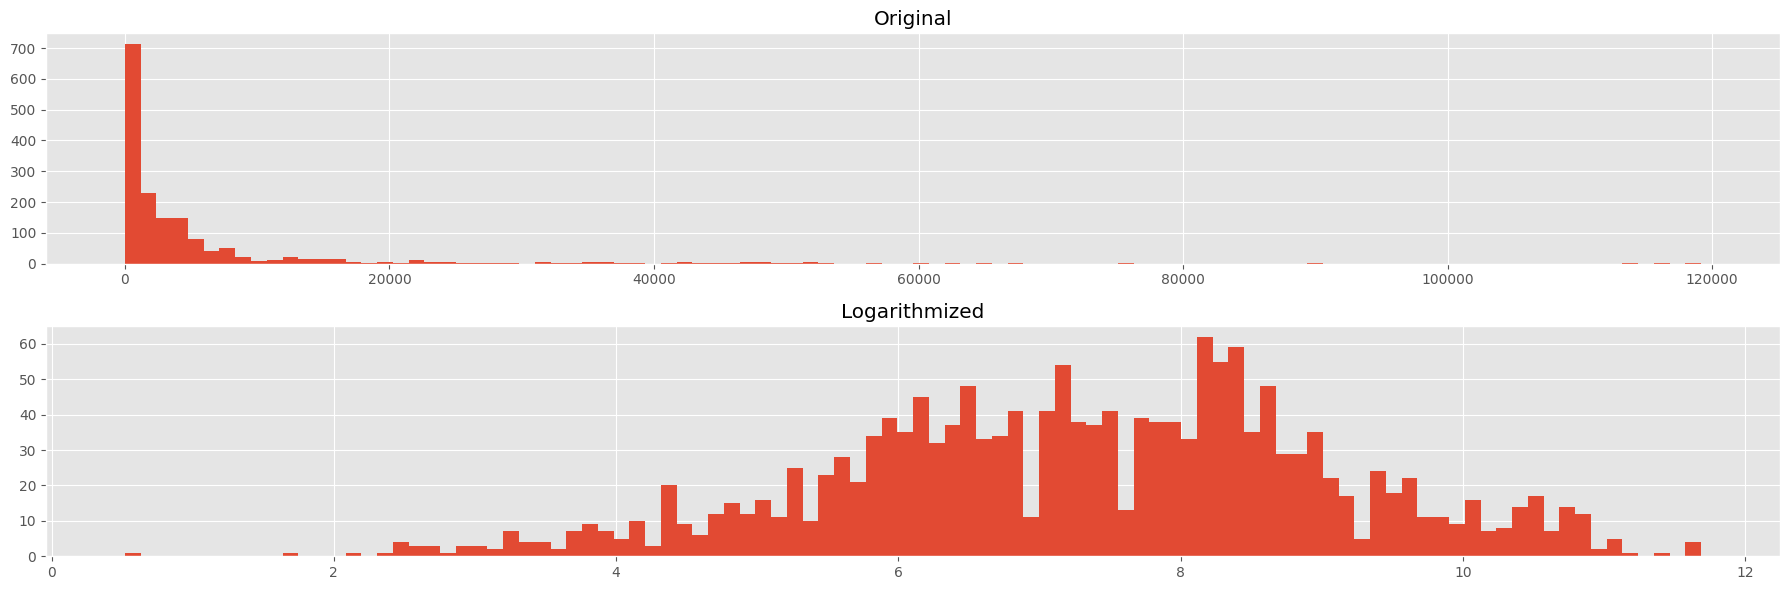

In [7]:
gdp_log = np.log(df['GDP'])

print(f'Skew:\nOriginal: {np.round(stats.skew(df['GDP']), 2)}')
print(f'Normalized: {np.round(stats.skew(gdp_log), 2)}')

fig, axs = plt.subplots(2, 1, figsize=(18, 6))

axs[0].hist(df['GDP'], bins=100)
axs[0].set_title('Original')

axs[1].hist(gdp_log, bins=100)
axs[1].set_title('Logarithmized')

plt.tight_layout()

### Testing the effect of taking logarithms of features on the accuracy of linear regression

In [8]:
exp = df.drop(['Country', 'Year'], axis=1)
exp = exp.astype('float64')
exp_log = exp.copy()

skew = pd.DataFrame(
    data=stats.skew(exp),
    index=exp.columns,
    columns=['Skew']
)
skew_cols = skew[((skew['Skew']>2) | (skew['Skew']<-2))].index

scaler = StandardScaler()
exp = pd.DataFrame(
    data=scaler.fit_transform(exp),
    columns=exp.columns
)

exp_log.loc[:, skew_cols] = np.log1p(exp_log[skew_cols])
scaler_log = StandardScaler()
exp_log = pd.DataFrame(
    data=scaler_log.fit_transform(exp_log),
    columns=exp_log.columns
)


In [9]:
X = exp.drop('Life expectancy ', axis=1)
y = exp['Life expectancy ']

X_log = exp_log.drop('Life expectancy ', axis=1)
y_log = exp_log['Life expectancy ']

def lin_reg_score(X, y):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

    reg = LinearRegression().fit(X_train, y_train)
    return reg.score(X_test, y_test)

print(f'W/O log: {lin_reg_score(X, y)}')
print(f'W/ log: {lin_reg_score(X_log, y_log)}')

W/O log: 0.8343045821598958
W/ log: 0.8572926731825358


## Recovering data w/ correlation coefficient

**Correlation Coefficient:**

$$
r(P, Q) = \frac{\sum^n_{i=1}p_iq_i - n\overline{p}\overline{q}}{(n-1)s_ps_q}
$$


**Recovery Formula:**

$$
P(A) = \overline{p} + \frac{\sum^n_{i=1}r(P, p_i)(p_i(A) - \overline{p_i})}{\sum_{i=1}^m|r(P, p_i)|}
$$

In [10]:
r = lambda p, q, n: ((p*q).sum() - n*p.mean()*q.mean()) / ((n - 1)*p.std()*q.std())

### Recovering by one feature

In [11]:
data = pd.DataFrame({
    'life expectancy': df['Life expectancy '], # target
    'schooling': df['Schooling']
})

nans_ids = rng.integers(low=0, high=data.shape[0], size=50)
nan_data = data.copy()
nan_data.loc[nans_ids, 'life expectancy'] = np.nan

complete_data = nan_data.dropna()

In [12]:
r_coeff = r(complete_data['life expectancy'], complete_data['schooling'], complete_data.shape[0])
r_coeff

np.float64(0.7286916967884599)

In [13]:
P_mean, p_mean = complete_data.mean()
p_A = data.loc[nans_ids]['schooling']

recovered_data = np.round(P_mean + np.sign(r_coeff) * (p_A - p_mean), 1)

R2 = 0.33


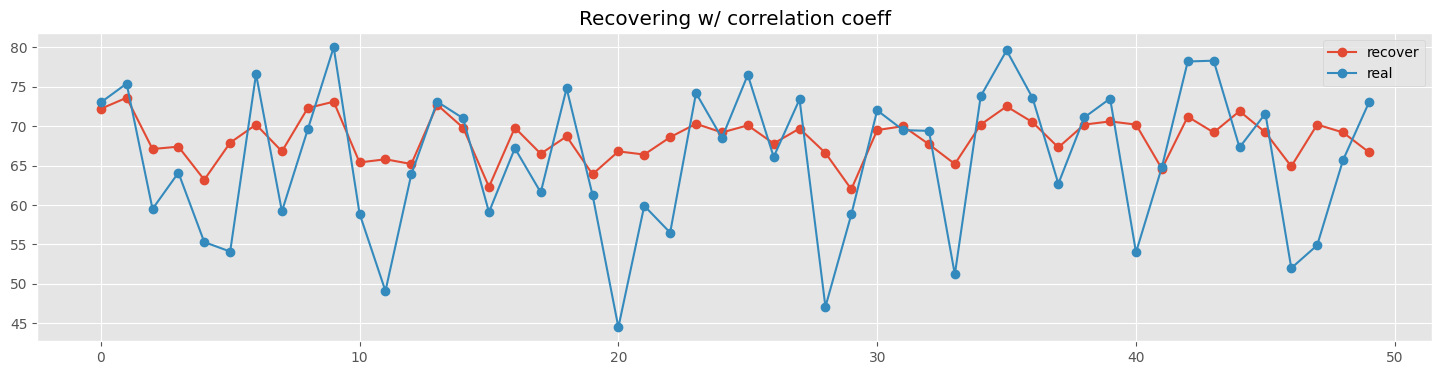

In [14]:
comparing = pd.DataFrame({
    'recover': recovered_data.to_list(),
    'real': data.loc[nans_ids, 'life expectancy'].to_list()
})
r2 = 1 - ((comparing['real'] - comparing['recover'])**2).sum() \
         / ((comparing['real'] - complete_data.mean()['life expectancy'])**2).sum()

print(f'R2 = {np.round(r2, 2)}')

plt.figure(figsize=(18, 4))
plt.plot(comparing, marker='o', label=comparing.columns)
plt.title('Recovering w/ correlation coeff')
plt.legend()

### Recovering by several features

In [15]:
df.drop(['Country', 'Year'], axis=1).corr()['Life expectancy '].sort_values()

,Life expectancy
Adult Mortality,-0.702523
HIV/AIDS,-0.592236
thinness 1-19 years,-0.457838
thinness 5-9 years,-0.457508
under-five deaths,-0.192265
infant deaths,-0.169074
Measles,-0.068881
Population,-0.022305
Total expenditure,0.174718
Hepatitis B,0.199935


In [16]:
features = [
    'Schooling',
    'Income composition of resources',
    'Adult Mortality',
    ' HIV/AIDS'
]

data = df[features + ['Life expectancy ']].copy()

nans_ids = rng.integers(low=0, high=data.shape[0], size=50)
nan_data = data.copy()
nan_data.loc[nans_ids, 'Life expectancy '] = np.nan

complete_data = nan_data.dropna()

In [17]:
p = complete_data.drop('Life expectancy ', axis=1)
q = complete_data['Life expectancy ']
n = complete_data.shape[0]

r_coeffs = ((p.T * q).T.sum() - n*p.mean()*q.mean()) / ((n - 1)*p.std()*q.std())
r_coeffs

,0
Schooling,0.727527
Income composition of resources,0.717622
Adult Mortality,-0.701420
HIV/AIDS,-0.593314


In [18]:
p_A = data.loc[nans_ids].drop('Life expectancy ', axis=1)
p.mean()

,0
Schooling,12.125891
Income composition of resources,0.630988
Adult Mortality,168.203877
HIV/AIDS,1.986116


In [20]:
recovery_data = q.mean() + (r_coeffs*(p_A - p.mean())).sum(axis=1) / np.abs(r_coeffs).sum()
recovery_data = recovery_data.map(lambda i: np.round(i, 2))

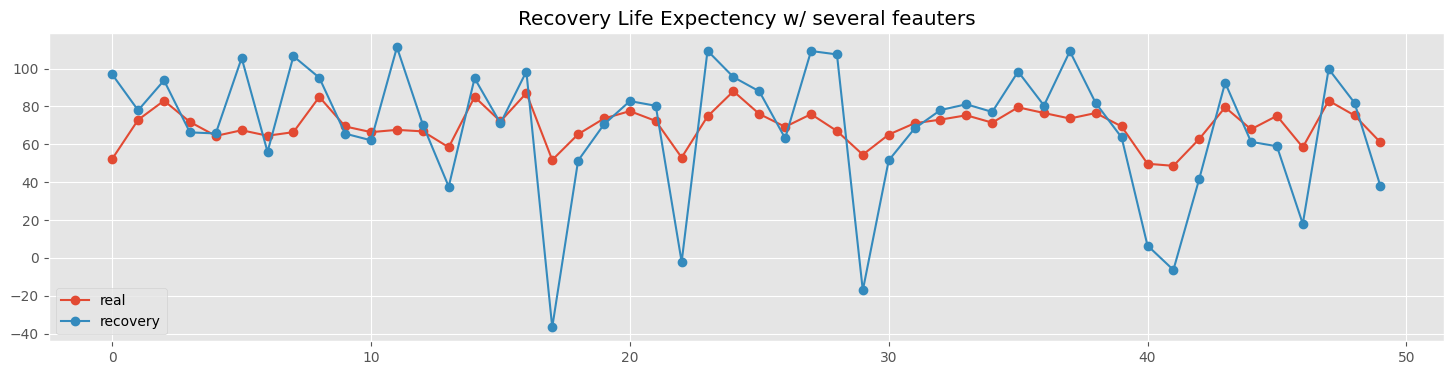

In [27]:
plt.figure(figsize=(18, 4))

plt.plot(data.loc[nans_ids]['Life expectancy '].to_list(), marker='o', label='real')
plt.plot(recovery_data.to_list(), marker='o', label='recovery')
plt.title('Recovery Life Expectency w/ several feauters')
plt.legend()
